<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/REVIEW_DOCTORADO3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bertopic
!pip install sentence-transformers ==5.2.0
!pip install umap-learn==0.5.9.post2
!pip install hdbscan
!pip install nltk
!pip install spacy
!pip install bibtexparser
!pip install scikit-learn
!pip install pybibx
!pip install tabulate
!pip install datasets==4.0.0
!pip install safetensors==0.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.0 MB/s eta 0:00:00
ERROR: Invalid requirement: '==5.2.0': Expected package name at the start of dependency specifier
    ==5.2.0
    ^
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: umap-learn
    Found existing installation: umap-learn 0.5.11
    Uninstalling umap-learn-0.5.11:
      Successfully uninstalled umap-learn-0.5.11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=e116374cdec67d373cf842a91714dd2514e49f627b423a05ad8fa7fccddb78e1
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9

In [2]:
import pandas as pd
import numpy as np
import textwrap
import bibtexparser
import re
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

In [3]:
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus31031912.bib'
database  = 'scopus';
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 1910 Documents were Found ( 1912 Documents and 2 Duplicates )

Article = 1910


In [4]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,1910
1,Abstracts,99.90%,1908
2,Affiliation,100.00%,1910
3,Author(s),100.00%,1910
4,DOI,96.34%,1840
5,Keywords - Authors,90.94%,1737
6,Keywords - Plus,84.29%,1610
7,References,0.00%,0
8,Year,100.00%,1910


In [5]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2000-2026
1,Total Number of Countries,111
2,Total Number of Institutions,2461
3,Total Number of Sources,541
4,Total Number of References,0
5,Total Number of Languages,1
6,--english (# of docs),1910
7,-//-,-//-
8,Total Number of Documents,1910
9,--Article,1910


In [6]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

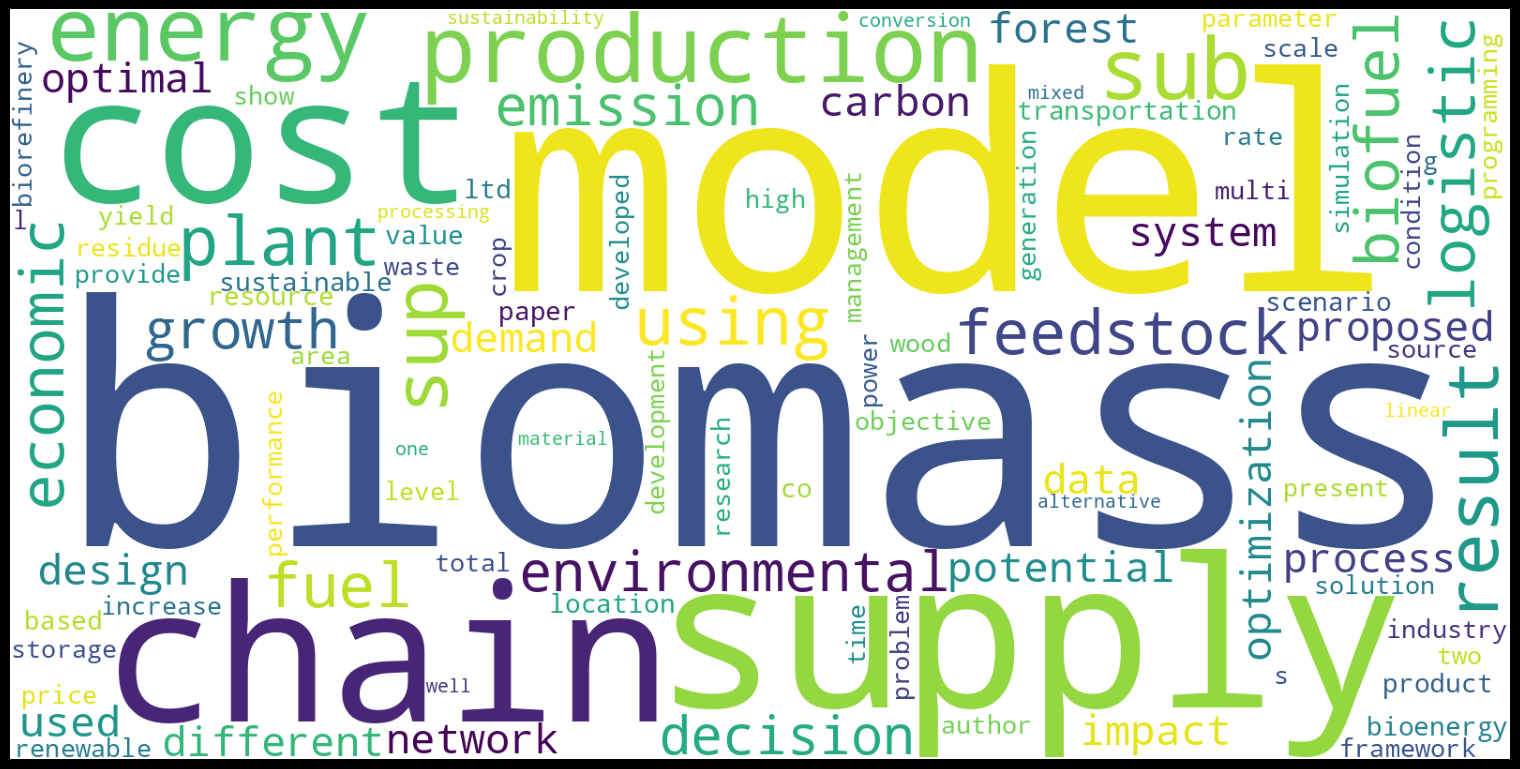

In [11]:
# WordCloud from the Abstracts, Title, Authors Keywords or Keywords Plus
# Arguments: entry             = 'abs', 'title', 'kwa', or 'kwp'
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = 100, rmv_custom_words = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"])

In [10]:
# Documents Projection based on Words. (An interactive plot). It returns the Projection (each document coordinate) and the Labels (each document cluster)
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            corpus_type       = 'abs', 'title', 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            custom_label      = A list of custom labels for each document. The user can define each document cluster;
#            custom_projection = A list of custom coordinates for each document. The user can define each document coordinate;
#            n_components      = Number of Dimensions;
#            n_clusters        = Only relevant if  cluster_method = 'kmeans'.Number of Clusters.;
#            node_labels       = If True, labels appear in nodes;
#            node_size         = Node size;
#            node_font_size    = Node font size;
#            tf_idf            = True or False (True -> The Cluster Algorithm will use the DTM to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            embeddings        = True or False (True -> The Cluster Algorithm will use the Word Embeddings to calculate each document Label. False -> The Cluster Algorithm will use the Coordinates to calculate each document Label);
#            model             = Only relevant if 'embeddings = True'. Specifies the used AI model. The default value is 'allenai/scibert_scivocab_uncased';
#            method            = 'tsvd' or 'umap' ('tsvd' -> Truncated SVD projection method is used. 'umap' -> UMAP projection method is used);
#            showlegend        = If True, shows legend;
#            cluster_method    = 'kmeans' or 'hdbscan';
#            min_size          = Only relevant if  cluster_method = 'hdbscan'. Minimum number of elements in a Cluster;
#            max_size          = Only relevant if  cluster_method = 'hdbscan'. Maximum number of elements in a Cluster
projection, labels = bibfile.docs_projection(view              = 'notebook',
                                             corpus_type       = 'kwa',
                                             stop_words        = ['en'],
                                             rmv_custom_words  = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"],
                                             custom_label      = [],
                                             custom_projection = [],
                                             n_components      = 2,
                                             n_clusters        = 8,
                                             node_labels       = True,
                                             node_size         = 12,
                                             node_font_size    = 5,
                                             tf_idf            = False,
                                             embeddings        = False,
                                             model             = 'allenai/scibert_scivocab_uncased',
                                             method            = 'umap',
                                             showlegend        = True,
                                             cluster_method    = 'hdbscan',
                                             min_size          = 5,
                                             max_size          = 50
                                             )

In [12]:
# Check Articles per Cluster
cluster      = 3
idx_articles = [i for i in range(0, labels.shape[0]) if labels[i] == cluster]
print(*idx_articles, sep = ', ')
# Contar cuántos documentos hay en ese cluster
print("Número de documentos en el clúster", cluster, ":", len(idx_articles))

26, 48, 194, 205, 343, 372, 388, 678, 1467
Número de documentos en el clúster 3 : 9


In [14]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            key               = 'abs', 'title', 'jou, 'kwa', or 'kwp';
#            stop_words        = A list of stopwords to clean the corpus. ['ar', 'bn', 'bg', 'cs', 'en', 'fi', 'fr', 'de', 'el', 'hi', 'he', 'hu', 'it', 'ja', 'ko',  'mr', 'fa', 'pl', 'pt-br', 'ro', 'ru', 'es', 'sv', 'sk', 'zh', 'th', 'uk'];
#                                'ar' = Arabic; 'bn' = Bengali; 'bg' = Bulgarian; 'cs' = Czech; 'en' = English; 'fi' = Finnish; 'fr' = French; 'de' = German; 'el' = Greek; 'he' = Hebrew;'hi' = Hindi; 'hu' = Hungarian; 'it' = Italian;
#                                'ja' = Japanese; 'ko' = Korean; 'mr' =  Marathi; 'fa' =  Persian; 'pl' =  Polish; 'pt-br' = Potuguese-Brazilian; 'ro' = Romanian; 'ru' = Russian; 'es' =  Spanish; 'sk' = Slovak; 'sv' = Swedish;
#                                'zh' = Chinese; 'th' = Thai; 'uk' = Ukrainian
#            rmv_custom_words  = A list of custom stopwords to clean the corpus;
#            topn              = Total number entities;
#            txt_font_size     = Font size of the text inside the bins;
#            start             = Start Year; -1 = all years
#            end               = End Year;   -1 = all years
bibfile.plot_evolution_year(view             = 'notebook',
                            stop_words       = [],
                            rmv_custom_words = ["a", "about", "above", "after", "again", "against", "ain", "al", "all", "am", "an", "análisis", "analysis", "and", "any", "application", "approach", "are", "aren", "aren't", "article", "as", "at", "based", "basado", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "can", "case", "caso", "con", "copyright", "couldn", "couldn't", "d", "de", "did", "didn", "didn't", "do", "does", "doesn", "doesn't", "doing", "doi", "don", "don't", "down", "during", "each", "efecto", "effect", "el", "elsevier", "en", "enfoque", "estudio", "evaluation", "few", "for", "from", "further", "ga", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", "he", "he'd", "he'll", "he's", "her", "here", "hers", "herself", "him", "himself", "his", "how", "http", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "inf", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", "its", "itself", "just", "la", "las", "ll", "los", "m", "ma", "me", "method", "metodología", "mightn", "mightn't", "more", "most", "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "para", "pdf", "por", "re", "reserved", "rights", "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "should've", "shouldn", "shouldn't", "so", "some", "springer", "study", "such", "system", "t", "than", "that", "that'll", "the", "their", "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "un", "una", "under", "unknown", "until", "up", "use", "uso", "ve", "very", "was", "wasn", "wasn't", "we", "we'd", "we'll", "we're", "we've", "were", "weren", "weren't", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", "wouldn't", "y", "you", "you'd", "you'll", "you're", "your", "yours", "yourself", "yourselves"],
                            key              = 'kwa',
                            topn             = 10,
                            txt_font_size    = 12,
                            start            = 2000,
                            end              = 2026)

In [15]:
# View Table
data_ep = bibfile.ask_gpt_ep
print(textwrap.fill(data_ep, 150))

 2000: modelling (1), logistic model (1), kinetics (1), solid-state fermentation (1), neural networks (1), monte carlo (1), solid-state cultivation
(1), growth curve (1), ergosterol (1), thunnus albacares (1) 2001: biomass (1), logistics (1), gasification (1), chp (1), stock assessment (1),
economies of scale (1), system analysis (1), south africa (1), growth (1), ecosystem (1) 2002: biomass (2), modeling (2), supply chain management (1),
solid-state fermentation (1), harvesting (1), model (1), agriculture (1), bacteria (1), aspergillus niger (1), pollution (1) 2003: biomass (1), supply
chain (1), logistics (1), uncertainty (1), gis (1), modelling (1), energy (1), linear programming (1), recycling (1), renewable (1) 2004: logistic
regression (2), biomass (1), logistic model (1), logistic function (1), growth model (1), sugar (1), yield loss (1), transect (1), tibetan plateau
(1), marine peptones (1) 2005: modelling (3), biomass (1), uncertainty (1), optimisation (1), mathematical model

In [16]:
# Arguments: view              = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn              = Most frequent n words
#            custom            = Plot specific words
bibfile.plot_evolution_year_complement(data_ep, view = 'notebook', topn = 10, custom = [])

In [17]:
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['kwa', 'aut', 'cout'], topn = [8, 3], rmv_unknowns = True)

In [18]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [20]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,All Years
united states of america,4,2,0,5,6,9,16,11,17,34,...,107,90,111,113,100,82,71,137,64,1705
china,0,0,0,0,6,2,18,3,3,0,...,46,49,28,32,84,67,153,186,43,847
india,0,0,0,0,1,0,0,3,4,7,...,11,30,11,52,11,45,56,63,17,399
canada,3,0,0,1,3,0,4,5,3,3,...,18,32,21,27,40,26,20,19,9,364
italy,0,0,3,0,0,1,7,0,6,7,...,32,17,16,15,27,12,22,18,0,321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
congo,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
mozambique,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
luxembourg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
uzbekistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [21]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 15)

In [22]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 15)

In [23]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
"lam, hon loong",0.0,0.0,0.0,0.0,1.0,2.0,0.0,4.0,1.0,2.0,...,3.0,6.0,2.0,2.0,1.0,1.0,3.0,0.0,1.0,0.0
"sowlati, taraneh",0.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,4.0,0.0,...,0.0,2.0,3.0,3.0,1.0,1.0,2.0,0.0,2.0,0.0
"ponce-ortega, josé maría",0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,...,4.0,1.0,1.0,0.0,1.0,3.0,0.0,0.0,1.0,1.0
"how, bing shen",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,2.0,2.0,2.0,2.0,3.0,0.0,0.0,0.0
"you, fengqi",0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,6.0,3.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"sokhansanj, shahab",1.0,1.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0,0.0,...,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
"shah, nilay",0.0,0.0,1.0,2.0,0.0,2.0,2.0,1.0,2.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
"marufuzzaman, mohammad",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,1.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,2.0
"bezzo, fabrizio",0.0,0.0,0.0,2.0,1.0,3.0,2.0,3.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"sahebi, hadi",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0


In [24]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 15)

In [25]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,2000,2003,2006,2007,2008,2009,2010,2011,2012,2013,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
university of british columbia,0.0,0.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0,3.0,...,4.0,3.0,5.0,3.0,1.0,3.0,3.0,0.0,3.0,0.0
mississippi state university,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,...,2.0,1.0,2.0,0.0,3.0,1.0,1.0,1.0,0.0,3.0
north dakota state university,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,4.0,...,2.0,1.0,2.0,3.0,1.0,1.0,3.0,1.0,1.0,0.0
university of tennessee,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,...,0.0,2.0,1.0,2.0,2.0,1.0,0.0,1.0,0.0,2.0
university of illinois at urbana-champaign,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,2.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
iran university of science and technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,1.0,3.0,3.0,3.0,2.0,1.0,2.0,0.0
oak ridge national laboratory,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,...,4.0,2.0,1.0,0.0,1.0,2.0,1.0,0.0,2.0,0.0
north carolina state university,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,2.0,2.0,1.0,3.0,3.0,0.0
university of tehran,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,4.0,2.0,2.0,1.0,4.0,1.0,2.0
university of california,0.0,1.0,1.0,0.0,1.0,1.0,3.0,2.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [26]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'cpc', topn = 15)

In [27]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Citations,Countries
0,United States of America,19735
1,China,5225
2,Canada,4875
3,United Kingdom,4670
4,Italy,3816
5,India,3134
6,Netherlands,2801
7,Iran,2641
8,Spain,2492
9,Germany,1875


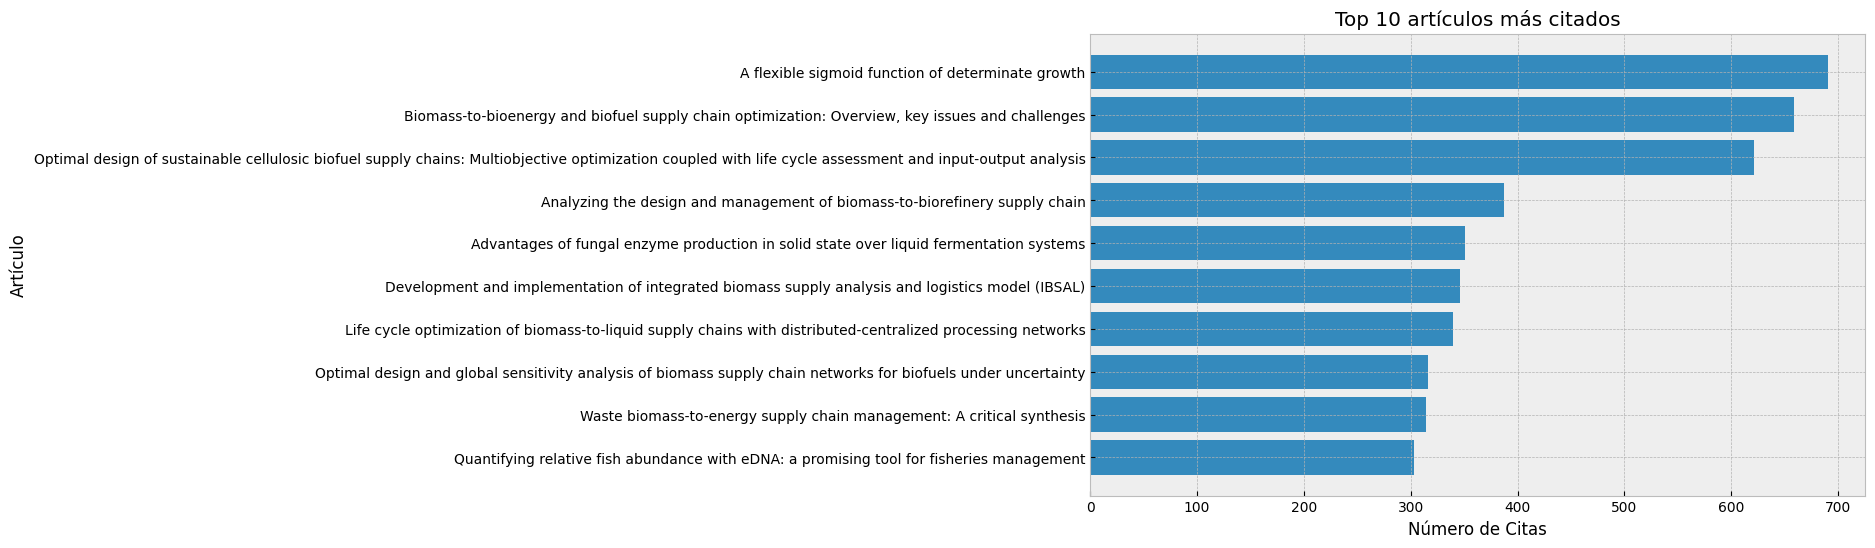

In [28]:
with open("/content/scopus31031912.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

titulos = []
citas = []

for entry in bib_database.entries:
    titulos.append(entry.get("title", "Sin título"))
    note_field = entry.get("note", "")
    match = re.search(r"Cited by:\s*(\d+)", note_field)
    citas.append(int(match.group(1)) if match else 0)

df_citas = pd.DataFrame({
    "Título": titulos,
    "Citas": citas
})

df_citas = df_citas.sort_values(by="Citas", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_citas["Título"].head(10), df_citas["Citas"].head(10))
plt.xlabel("Número de Citas")
plt.ylabel("Artículo")
plt.title("Top 10 artículos más citados")
plt.gca().invert_yaxis()
plt.show()


# **Análisis de redes de conocimiento**

In [29]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = ["colombia"])

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [30]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 20, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [31]:
# Genera la tabla de valores
tabla_centralidad = bibfile.table_centr
print(tabla_centralidad.head(50))

                                Name  Node  Eigenvector
0                            biomass   k_0     0.262690
1                       optimization   k_1     0.235962
2                       supply chain   k_2     0.233655
3                          bioenergy   k_3     0.214771
4                     sustainability   k_4     0.181523
6                            biofuel   k_6     0.180390
7                          logistics   k_7     0.173060
9                        biorefinery   k_9     0.160780
10                          biofuels  k_10     0.149221
5               biomass supply chain   k_5     0.140679
8              life cycle assessment   k_8     0.138643
16           supply chain management  k_16     0.128306
11                       uncertainty  k_11     0.126251
12                        simulation  k_12     0.122591
14                               gis  k_14     0.121228
13                  renewable energy  k_13     0.118102
15         supply chain optimization  k_15     0

In [32]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 20, node_labels = True, label_type = 'name', centrality = 'betw')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



In [33]:
tabla_betweenness = bibfile.table_centr

# 3. Visualizar los 30 términos con mayor poder de intermediación
print("Top 30 Nodos por Betweenness Centrality (Puentes del conocimiento):")
print(tabla_betweenness.sort_values(by='Betweenness', ascending=False).head(50))

Top 30 Nodos por Betweenness Centrality (Puentes del conocimiento):
                             Name   Node  Betweenness
0                         biomass    k_0     0.199886
2                    supply chain    k_2     0.113469
1                    optimization    k_1     0.102704
3                       bioenergy    k_3     0.066455
4                  sustainability    k_4     0.057893
6                         biofuel    k_6     0.035654
7                       logistics    k_7     0.033813
9                     biorefinery    k_9     0.030082
8           life cycle assessment    k_8     0.027311
5            biomass supply chain    k_5     0.022044
10                       biofuels   k_10     0.018370
11                    uncertainty   k_11     0.014729
12                     simulation   k_12     0.014581
15      supply chain optimization   k_15     0.014175
14                            gis   k_14     0.013235
19                     bioethanol   k_19     0.012230
16        supp

# *Colaboración entre autores*

In [34]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 35, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



# **Preparando clustering de los documentos**

In [35]:
# Lectura de datasets y del modelo pre-entrenado
from datasets import load_dataset # 4.0.0
from sentence_transformers import SentenceTransformer # 5.2.0
from safetensors.numpy import save_file, load_file # 0.7.0. Opcional para guardar y recargar embeddings obtenidos

# Reducción de dimensionalidad y clustering
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

# Exploración y visualización de datos
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
import pandas as pd
import itertools

# Fijar semillas de generadores aleatorios
import torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [36]:
from datasets import Dataset

# Configuración de ruta
RUTA_BIB = '/content/scopus31031912.bib'
RUTA_PARQUET = '/content/dataset_scopus.parquet'

# Paso 1: Leer el archivo .bib
with open(RUTA_BIB, encoding='utf-8') as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

# Paso 2: Convertir a DataFrame de Pandas
df = pd.DataFrame(bib_database.entries)

# Paso 3: Guardar como Parquet (Opcional, pero recomendado para persistencia)
df.to_parquet(RUTA_PARQUET)

# Paso 4: Cargar como un objeto Dataset de Hugging Face
# Ahora sí usamos el cargador de parquet porque el archivo ya tiene ese formato
dataset_tr = Dataset.from_pandas(df)

# Verificar el resultado
print(dataset_tr)
print(dataset_tr[0])

Dataset({
    features: ['note', 'source', 'publication_stage', 'type', 'abbrev_source_title', 'language', 'issn', 'publisher', 'correspondence_address', 'keywords', 'author_keywords', 'abstract', 'affiliations', 'url', 'doi', 'pages', 'volume', 'journal', 'year', 'title', 'author', 'ENTRYTYPE', 'ID', 'coden', 'number', 'pmid', 'isbn', 'editor'],
    num_rows: 1823
})
{'note': 'Cited by: 0', 'source': 'Scopus', 'publication_stage': 'Final', 'type': 'Article', 'abbrev_source_title': 'Sustainable Energy Technol. Assess.', 'language': 'English', 'issn': '22131388', 'publisher': 'Elsevier Ltd', 'correspondence_address': 'L. Wan; School of Economics and Management, Henan University of Urban Construction, Pingdingshan, Henan, 467036, China; email: 20141035@huuc.edu.cn', 'keywords': "Iowa; United States; Benchmarking; Biomass; Cellulosic ethanol; Cost benefit analysis; Economic analysis; Feedstocks; Gasification; Integer programming; Investments; Logistics; Profitability; Risk perception; Sal

In [37]:
resumenes = dataset_tr['abstract']
titulos = dataset_tr['title']

In [38]:
# Extraer un índice aleatorio
N = len(resumenes)
idx = random.randint(0, N)

# Extraer texto y darle formato
texto = resumenes[idx]
texto = textwrap.fill(texto, 100)

# Imprimir título y resumen
print(f"Título: {titulos[idx]}")
print('-'*25)
print(f"Resumen: {texto}")

Título: Newly developed water productivity and harvest index models for maize in an arid region
-------------------------
Resumen:                              Simulating yield response to different irrigation scenarios is
important for agricultural production, especially in the arid region where agriculture depends
heavily on irrigation. To better predict yield under different irrigation scenarios, the variation
of normalized water productivity (WP                             <sup>*</sup>
) over the whole growing period of maize for seed production and the effect of different irrigation
treatments on harvest index (HI) were investigated using field experiments from 2012 to 2015 in an
arid region of northwest China. Two new non-linear dynamic WP
<sup>*</sup>                              (WP                             <sup>*</sup>
<sub>KR-L</sub>                              and WP                             <sup>*</sup>
<sub>KR-S</sub>                             ) models derived fro

In [39]:
# Reemplaza los valores nulos (NaN) por una cadena vacía
df['abstract'] = df['abstract'].fillna('')

# Luego extraes la lista nuevamente
resumenes = df['abstract'].tolist()

# Ahora tu código original funcionará sin errores
sizes = [len(text.split()) for text in resumenes]

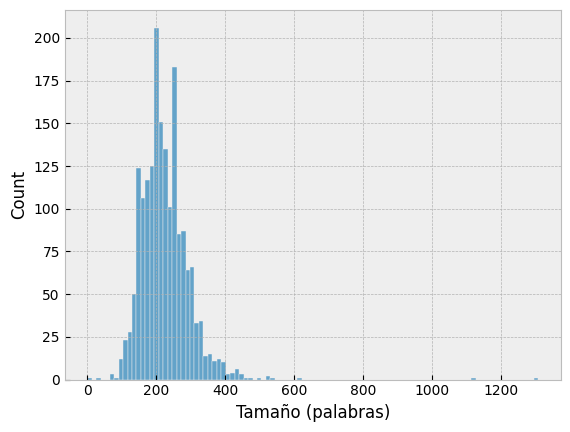

In [40]:
# Tamaños de los textos
sizes = []
for text in resumenes:
    words = text.split()
    sizes.append(len(words))

# Histograma
sns.histplot(sizes)
plt.xlabel("Tamaño (palabras)");

In [45]:
#RUTA_MODELO = 'google/embeddinggemma-300m'  # Modelo alternativo
RUTA_MODELO = 'sentence-transformers/sentence-t5-base'
embedding_model = SentenceTransformer(RUTA_MODELO)

Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

In [46]:
embedding_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'T5EncoderModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
  (3): Normalize()
)

In [48]:
embeddings = embedding_model.encode(resumenes, show_progress_bar=True)

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

In [49]:
print("Ejemplo de un 'embedding':")
print(embeddings[10])
print("-"*20)
print(f"Tamaño de los embeddings: {embeddings.shape}")

Ejemplo de un 'embedding':
[-4.6883e-03 -3.5919e-02  2.0279e-02  1.8478e-02  5.5695e-03 -2.3499e-03
 -3.9032e-02  3.0289e-02 -1.4236e-02 -8.4534e-03  4.6661e-02 -6.7932e-02
  4.1565e-02 -2.5620e-02  5.3467e-02  2.1057e-02 -2.4052e-03 -1.9638e-02
 -8.2474e-03  2.2614e-02  2.8015e-02 -3.7292e-02 -3.7262e-02  4.0314e-02
 -8.0261e-03  8.7204e-03  3.3173e-02 -1.7700e-02 -2.8336e-02  2.1927e-02
  9.4849e-02 -3.4676e-03 -2.2827e-02  4.2419e-02 -3.4424e-02 -1.7703e-05
 -2.9282e-02 -5.2124e-02 -3.9459e-02  2.8503e-02  2.1988e-02 -3.1555e-02
 -5.0903e-02  1.4198e-02 -4.7302e-02 -9.8419e-03  3.0670e-02  7.3181e-02
  4.6539e-03 -7.8491e-02 -5.3833e-02 -4.1016e-02 -5.8044e-02 -2.4292e-02
 -3.3234e-02 -2.1240e-02 -1.1398e-02  5.2738e-04  1.5038e-02 -6.4621e-03
 -8.0933e-02  1.5900e-02 -4.3274e-02 -4.1901e-02 -4.5563e-02  1.0841e-02
 -5.2826e-02 -3.0563e-02  3.5370e-02 -1.6220e-02  3.9520e-02 -9.8495e-03
 -3.7079e-02 -2.4719e-03 -2.0309e-02 -5.9814e-02 -3.8574e-02  2.0847e-03
  6.2317e-02 -2.5635e-02

In [50]:
# Guardar con "safetensors"
save_file({"embeddings": embeddings}, "embs_resumenes_esp_tr.safetensors")

# **Reducción de la dimensionalidad**

In [51]:
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)
embeddings_reducidos = umap_model.fit_transform(embeddings)

En este punto tendremos la misma cantidad de embeddings original, pero ahora en lugar de usar vectores de 768 elementos para representarlos usaremos vectores de 5 elementos

In [52]:
embeddings_reducidos.shape

(1823, 5)

# **Aplicación del clustering de texto**

Implementamos el método HDBSCAN definiendo dos hiper-parámetros:

"min_samples": cuántos puntos vecinos de otro punto se consideran para determinar si dicho punto es "core". Entre más grande sea "min_samples" más puntos etiquetados como ruido (-1) tendremos
"min_cluster_size": el número mínimo de datos para considerar que tenemos un "cluster"
Y lo que nos interesa es encontrar una combinación adecuada de hiper-parámetros que retorne un puntaje silueta adecuado y que a la vez no genere un número elevado de "outliers".

Así que seguiremos este procedimiento:

a) Definiremos un rango de valores para "min_samples" y para "min_cluster_size"
b) Por cada combinación de valores de estos dos hiper-parámetros:
    -Construiremos un modelo HDBSCAN
    -Calcularemos y almacenaremos el puntaje silueta, el porcentaje de "outliers" y el número de agrupaciones generadas
c) Al final buscaremos una combinación de hiper-parámetros donde el puntaje silueta resulte adecuado (mayor que 0.5), el porcentaje de "outliers" no sea tan elevado y el número de clusters no resulte ni excesivamente pequeño ni excesivamente grande.

In [53]:
# Combinatoria de MS y MCS
MS = range(2, 31, 4) # 2, , 6, ... 30
MCS = range(2, 31, 4) # 2,  6,... 30

# Todos los posibles pares de combinaciones
pares = list(itertools.product(MS, MCS))
npares = len(pares)

resultados = []
for i, par in enumerate(pares):
    print(f"Probando combinación {i+1}/{npares} ({par})...")
    ms, mcs = par[0], par[1]
    hdb = HDBSCAN(min_samples=ms, min_cluster_size=mcs).fit(embeddings_reducidos)
    labels = hdb.labels_

    # Calcular porcentaje de ruido
    pctj_ruido = np.sum(labels == -1) / len(labels)

    # Calcular puntaje silueta sólo en datos que no sean ruido
    idx = labels != -1
    if np.sum(idx) > 0:
        n_clusters = len(set(labels[idx]))
        if n_clusters > 1:
            score = silhouette_score(embeddings_reducidos[idx], labels[idx])
            resultados.append({'min_samples': ms, 'min_cluster_size': mcs,
                               'silueta': score, 'ruido': pctj_ruido, 'n_clusters': n_clusters})

# Crear dataframe de resultados y ordenar por puntaje silueta
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('silueta', ascending=False)

Probando combinación 1/64 ((2, 2))...
Probando combinación 2/64 ((2, 6))...
Probando combinación 3/64 ((2, 10))...
Probando combinación 4/64 ((2, 14))...
Probando combinación 5/64 ((2, 18))...
Probando combinación 6/64 ((2, 22))...
Probando combinación 7/64 ((2, 26))...
Probando combinación 8/64 ((2, 30))...
Probando combinación 9/64 ((6, 2))...
Probando combinación 10/64 ((6, 6))...
Probando combinación 11/64 ((6, 10))...
Probando combinación 12/64 ((6, 14))...
Probando combinación 13/64 ((6, 18))...
Probando combinación 14/64 ((6, 22))...
Probando combinación 15/64 ((6, 26))...
Probando combinación 16/64 ((6, 30))...
Probando combinación 17/64 ((10, 2))...
Probando combinación 18/64 ((10, 6))...
Probando combinación 19/64 ((10, 10))...
Probando combinación 20/64 ((10, 14))...
Probando combinación 21/64 ((10, 18))...
Probando combinación 22/64 ((10, 22))...
Probando combinación 23/64 ((10, 26))...
Probando combinación 24/64 ((10, 30))...
Probando combinación 25/64 ((14, 2))...
Proband

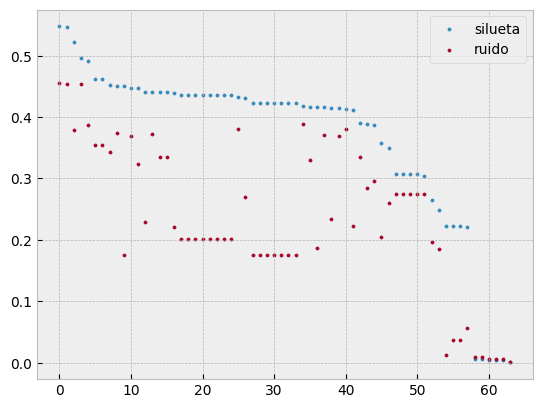

In [54]:
plt.scatter(range(len(df_resultados)),df_resultados['silueta'],s=5, label='silueta')
plt.scatter(range(len(df_resultados)),df_resultados['ruido'],s=5, label='ruido')
plt.legend();

In [55]:
df_resultados.head(25)

,min_samples,min_cluster_size,silueta,ruido,n_clusters
18,10,10,0.547724,0.455293,31
17,10,6,0.546999,0.454196,33
9,6,6,0.522252,0.379046,62
16,10,2,0.496058,0.454196,52
10,6,10,0.492045,0.386725,37
44,22,18,0.462218,0.354361,11
45,22,22,0.462218,0.354361,11
36,18,18,0.452278,0.342841,12
6,2,26,0.451014,0.374109,18
0,2,2,0.449800,0.174986,441


In [57]:
hdbscan = HDBSCAN(min_samples=6, min_cluster_size=6)
clusters = hdbscan.fit_predict(embeddings_reducidos)
clusters

array([60, 36, -1, ..., -1,  3,  3])

In [58]:
len(set(clusters))

63

In [59]:
# Porcentaje de outliers
pctj_outliers = np.sum(clusters == -1) / len(clusters)
print(f"Porcentaje de outliers: {100*pctj_outliers:.1f} %")

Porcentaje de outliers: 37.9 %


*Exploración de los "clusters" generados*

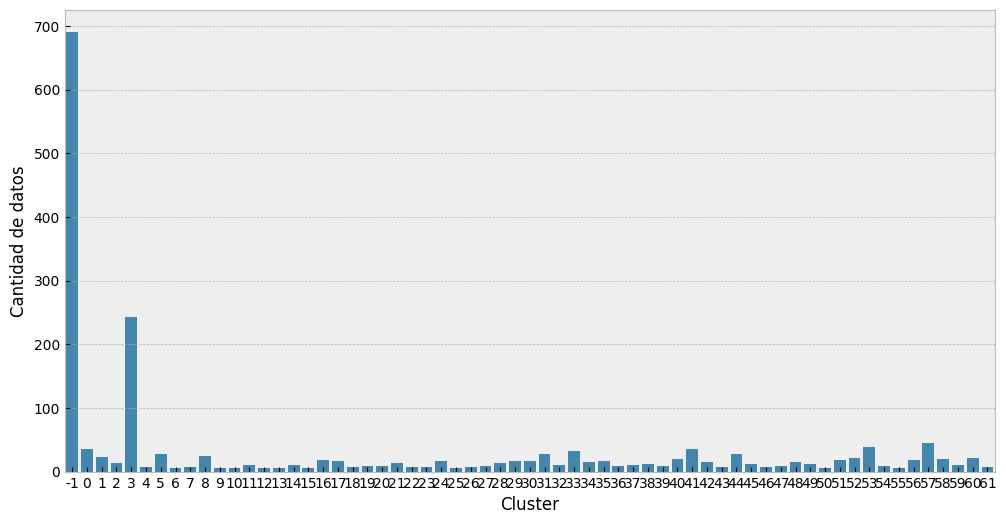

In [60]:
# Distribución de las agrupaciones
fig, ax = plt.subplots(figsize=(12,6))
df_clusters = pd.Series(clusters).value_counts()
sns.barplot(x=df_clusters.index, y=df_clusters.values)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de datos');

In [62]:
# Exploración
# label = -1 # outliers
label = 19

idxs = np.where(clusters==label)[0]

for i in range(3):
    idx = np.random.choice(idxs).item()
    resumen = resumenes[idx]
    resumen = textwrap.fill(resumen, width=100)
    print(f"--- Documento {idx} ---")
    print(resumen)
    print("\n")

--- Documento 1724 ---
In this paper, a decision support system (DSS) for multi-biomass energy conversion applications is
presented. The system in question aims at supporting an investor by thoroughly assessing an
investment in locally existing multi-biomass exploitation for tri-generation applications
(electricity, heating and cooling), in a given area. The approach followed combines use of holistic
modelling of the system, including the multi-biomass supply chain, the energy conversion facility
and the district heating and cooling network, with optimization of the major investment-related
variables to maximize the financial yield of the investment. The consideration of multi-biomass
supply chain presents significant potential for cost reduction, by allowing spreading of capital
costs and reducing warehousing requirements, especially when seasonal biomass types are concerned.
The investment variables concern the location of the bioenergy exploitation facility and its sizing,
as well a

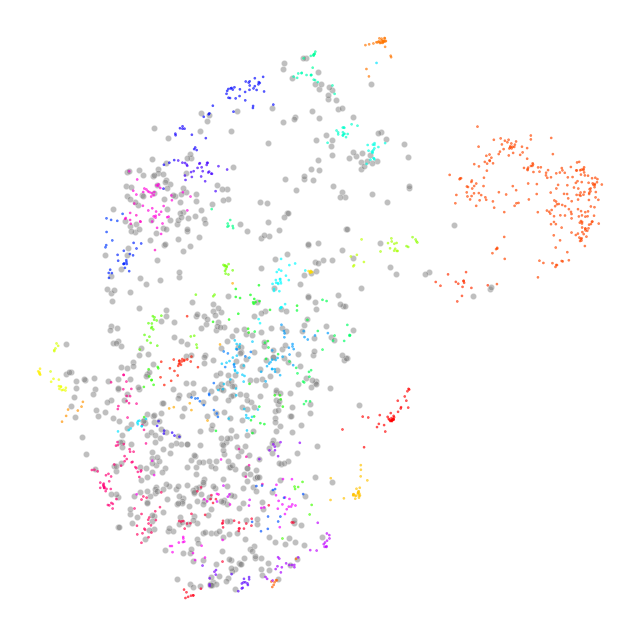

In [68]:
# Exploración como gráficos 2d
embeddings_2D = UMAP(
    n_components = 2,
    min_dist = 0.0,
    metric = "cosine",
    random_state = 42,
    n_jobs = 1
).fit_transform(embeddings)

# Crear un DataFrame con la información 2D
df = pd.DataFrame(embeddings_2D, columns=["x", "y"])
df["titulo"] = titulos
df["cluster"] = [str(c) for c in clusters]

# Crear dataframes de clusters y de outliers
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

# Y hacer gráficos de dispersión
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(outliers_df, x="x", y="y", alpha=0.5, s=20,
            c="grey")
plt.scatter(clusters_df.x, clusters_df.y,
            c=clusters_df.cluster.astype(int),
            alpha=0.6, s=2, cmap="hsv")
plt.axis("off");

In [69]:
clusters_df

,x,y,titulo,cluster
0,-1.117525,-3.332948,Comprehensive techno economic and logistic ass...,60
1,-0.555999,-1.659567,Forest 4.0: Technologies and digitalization to...,36
4,-1.007768,-3.280695,Large-scale spatially explicit analysis of car...,55
5,-0.789103,-1.797833,Robust optimization of regional biomass supply...,33
6,-1.251284,-3.199910,A multi-unit model for the biorefinery supply ...,59
...,...,...,...,...
1815,1.369713,-2.420780,Heat integration study on biomass gasification...,0
1816,-1.806858,-3.257101,Simulation modeling framework for uncovering s...,58
1818,4.103359,0.158567,High production of hyaluronic and lactic acids...,3
1821,3.787479,0.431468,Fundamental Escherichia coli Biochemical Pathw...,3


In [70]:
!pip install bertopic==0.17.4 nltk==3.9.1 langdetect==1.0.9

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a09ab94c29608dd3547f37596ff8101529e76c2f0eabf34345d9f15d5f4e2535
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [71]:
# Reducción de dimensionalidad, clustering y modelado de tópicos
from umap import UMAP # 0.5.9.post2
from sklearn.cluster import HDBSCAN
from bertopic import BERTopic

# Procesamiento adicional del texto
from langdetect import detect
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# **Uso de Bertopic**

In [72]:
# Crear instancia de BERTopic especificando únicamente el método de clustering
topic_model = BERTopic(
    # embedding_model=embedding_model,
    top_n_words = 8, # el número de palabras clave a extraer por cada tópico (10 por defecto)
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    verbose=True)
topic_model.fit(resumenes)

2026-04-04 02:59:38,721 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2026-04-04 02:59:51,894 - BERTopic - Embedding - Completed ✓
2026-04-04 02:59:51,897 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:00:02,159 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:00:02,161 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:00:02,256 - BERTopic - Cluster - Completed ✓
2026-04-04 03:00:02,266 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:00:03,095 - BERTopic - Representation - Completed ✓


In [73]:
loaded = load_file("/content/embs_resumenes_esp_tr.safetensors")
embeddings = loaded["embeddings"]

In [74]:
# Crear instancia de BERTopic especificando únicamente el método de clustering
topic_model = BERTopic(
    # embedding_model=embedding_model,
    top_n_words = 8, # el número de palabras clave a extraer por cada tópico (10 por defecto)
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    verbose=True)

topic_model.fit(resumenes, np.array(embeddings));

2026-04-04 03:00:38,803 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:00:56,354 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:00:56,356 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:00:56,435 - BERTopic - Cluster - Completed ✓
2026-04-04 03:00:56,441 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:00:57,223 - BERTopic - Representation - Completed ✓


*Exploración de topicos*

In [75]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_the_of_and_to,"[the, of, and, to, in, biomass, for, is]","[Demand for alternative feedstocks for fuels, ..."
1,0,242,0_growth_was_fermentation_and,"[growth, was, fermentation, and, were, of, con...",[Tertiary wastewater treatment by microalgae h...
2,1,45,1_network_problem_algorithm_the,"[network, problem, algorithm, the, proposed, m...",[This paper addresses an integrated biomass pr...
3,2,39,2_wood_costs_energy_chips,"[wood, costs, energy, chips, forest, supply, o...",[The promotion of electric energy production f...
4,3,36,3_forest_models_tree_agb,"[forest, models, tree, agb, stand, were, leaf,...",[This paper aims to assess the performance of ...
...,...,...,...,...,...
58,57,6,57_adoption_households_lpg_cooking,"[adoption, households, lpg, cooking, clean, ic...",[Understanding and integrating the user’s deci...
59,58,6,58_hemp_hasup1sup_kg_contaminated,"[hemp, hasup1sup, kg, contaminated, protein, f...",[The objectives of this study were to assess t...
60,59,6,59_methane_crs_pretreated_ad,"[methane, crs, pretreated, ad, pw, gompertz, w...",[Anaerobic digestion (AD) can be used to conve...
61,60,6,60_chopped_switchgrass_bulk_density,"[chopped, switchgrass, bulk, density, kgmsup3s...",[The benefits of particle size reduction and m...


*Mejorando los topicos obtenidos*

In [76]:
# Descargar listado de stop words en ingles
nltk.download('stopwords')
stop_words = stopwords.words('english')
stop_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [77]:
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    strip_accents=None)

In [78]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
verbose=True)

topic_model.fit(resumenes, np.array(embeddings)); # <--- clave: usar los embeddings de textos sólo en ingles

2026-04-04 03:06:27,586 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:06:47,735 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:06:47,736 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:06:47,786 - BERTopic - Cluster - Completed ✓
2026-04-04 03:06:47,791 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:06:48,207 - BERTopic - Representation - Completed ✓


In [79]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_supply_biomass_chain_model,"[supply, biomass, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...
1,0,242,0_growth_fermentation_concentration_logistic,"[growth, fermentation, concentration, logistic...",[Tertiary wastewater treatment by microalgae h...
2,1,45,1_network_problem_algorithm_proposed,"[network, problem, algorithm, proposed, model,...",[This research presents a two-stage stochastic...
3,2,39,2_wood_costs_chips_forest,"[wood, costs, chips, forest, energy, logging, ...",[In Australia the use of forest biomass has be...
4,3,36,3_forest_models_tree_agb,"[forest, models, tree, agb, stand, leaf, trees...",[Introduction: Chinese fir (Cunninghamia lance...
...,...,...,...,...,...
58,57,6,57_adoption_households_lpg_cooking,"[adoption, households, lpg, cooking, clean, ic...","[This study explores how gender, socio-economi..."
59,58,6,58_hemp_hasup1sup_kg_contaminated,"[hemp, hasup1sup, kg, contaminated, protein, f...",[The objectives of this study were to assess t...
60,59,6,59_methane_crs_pretreated_pw,"[methane, crs, pretreated, pw, ad, gompertz, x...",[Anaerobic digestion (AD) can be used to conve...
61,60,6,60_chopped_switchgrass_bulk_density,"[chopped, switchgrass, bulk, density, kgmsup3s...",[The benefits of particle size reduction and m...


In [80]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    vectorizer_model=vectorizer_model, ### Clave: NO CAMBIAR EMBEDDINGS, EN LOS EMBEDDINGS SÍ SE USAN LOS STOP WORDS
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit_transform(resumenes, np.array(embeddings));

2026-04-04 03:07:56,724 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:08:13,407 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:08:13,408 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:08:13,477 - BERTopic - Cluster - Completed ✓
2026-04-04 03:08:13,477 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 03:08:13,938 - BERTopic - Representation - Completed ✓
2026-04-04 03:08:13,939 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 03:08:13,965 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:08:14,407 - BERTopic - Representation - Completed ✓
2026-04-04 03:08:14,410 - BERTopic - Topic reduction - Reduced number of topics from 63 to 52


In [81]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...
1,0,242,0_growth_fermentation_concentration_logistic,"[growth, fermentation, concentration, logistic...",[Tertiary wastewater treatment by microalgae h...
2,1,115,1_supply_chain_network_model,"[supply, chain, network, model, proposed, prob...","[Recently, the biomass has gained considerable..."
3,2,107,2_biodiesel_supply_energy_environmental,"[biodiesel, supply, energy, environmental, cha...",[The ever-increasing energy demand and harmful...
4,3,59,3_wood_forest_costs_supply,"[wood, forest, costs, supply, energy, chips, b...",[Forest biomass is one of the renewable source...
5,4,36,4_forest_models_tree_agb,"[forest, models, tree, agb, stand, leaf, trees...",[This paper aims to assess the performance of ...
6,5,35,5_hydrogen_gasification_production_plant,"[hydrogen, gasification, production, plant, en...","[In this study, we propose a novel optimizatio..."
7,6,28,6_data_fishing_estimates_msy,"[data, fishing, estimates, msy, fish, fishery,...","[An integrated, age-structured model was fitte..."
8,7,27,7_beccs_carbon_power_ccs,"[beccs, carbon, power, ccs, emissions, cosub2s...",[The UK is the first major economy to legislat...
9,8,27,8_forest_wood_carbon_pine,"[forest, wood, carbon, pine, bioenergy, scenar...",[Forest bioenergy value chains can offer attra...


# **Exploración de topicos**

In [82]:
# Cada valor es el c-TF-IDF normalizado
topic_model.get_topic(15)

[('pet', np.float64(0.0359879849365693)),
 ('op', np.float64(0.026949823742844187)),
 ('energy', np.float64(0.024578535160235813)),
 ('biogas', np.float64(0.02159291454898075)),
 ('animal', np.float64(0.0196105363499964)),
 ('plastics', np.float64(0.01946913905954323)),
 ('sustainable', np.float64(0.0181716454550198)),
 ('production', np.float64(0.01678603036989849)),
 ('waste', np.float64(0.014916787356086675)),
 ('use', np.float64(0.014819565885404423))]

In [83]:
# Info a nivel de documento
topic_model.get_document_info(resumenes)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,The commercial deployment of cellulosic biofue...,1,1_supply_chain_network_model,"[supply, chain, network, model, proposed, prob...","[Recently, the biomass has gained considerable...",supply - chain - network - model - proposed - ...,0.840028,False
1,"Currently, there is an increasing pressure to ...",2,2_biodiesel_supply_energy_environmental,"[biodiesel, supply, energy, environmental, cha...",[The ever-increasing energy demand and harmful...,biodiesel - supply - energy - environmental - ...,0.973490,False
2,We introduce a novel method of evaluating risk...,-1,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...,biomass - supply - chain - model - energy - co...,0.000000,False
3,This paper first examines the components of lo...,-1,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...,biomass - supply - chain - model - energy - co...,0.000000,False
4,The large-scale production of cellulosic biofu...,45,45_concepts_ccs_gbr_biorefineries,"[concepts, ccs, gbr, biorefineries, biorefiner...",[Biofuels and biochemicals play significant ro...,concepts - ccs - gbr - biorefineries - biorefi...,1.000000,False
...,...,...,...,...,...,...,...,...
1818,"The combined production of biomass, hyaluronic...",0,0_growth_fermentation_concentration_logistic,"[growth, fermentation, concentration, logistic...",[Tertiary wastewater treatment by microalgae h...,growth - fermentation - concentration - logist...,1.000000,False
1819,Theory predicts that the effects of regional r...,-1,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...,biomass - supply - chain - model - energy - co...,0.000000,False
1820,This study investigates the logistics of suppl...,-1,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...,biomass - supply - chain - model - energy - co...,0.000000,False
1821,Cells grow by oxidizing nutrients using a comp...,0,0_growth_fermentation_concentration_logistic,"[growth, fermentation, concentration, logistic...",[Tertiary wastewater treatment by microalgae h...,growth - fermentation - concentration - logist...,1.000000,False


In [84]:
# Listado completo de tópicos
topic_model.get_topics()

{-1: [('biomass', np.float64(0.01379767441168569)),
  ('supply', np.float64(0.013759590268303425)),
  ('chain', np.float64(0.012088830122388627)),
  ('model', np.float64(0.010500841701925754)),
  ('energy', np.float64(0.009882817779669099)),
  ('cost', np.float64(0.009653859788435104)),
  ('study', np.float64(0.009407899330065594)),
  ('production', np.float64(0.009106053588576307)),
  ('results', np.float64(0.008012006917809702)),
  ('environmental', np.float64(0.007787443894863847))],
 0: [('growth', np.float64(0.029639079308550063)),
  ('fermentation', np.float64(0.02033708521033091)),
  ('concentration', np.float64(0.018650991652996496)),
  ('logistic', np.float64(0.018169067731719408)),
  ('production', np.float64(0.017124052897842884)),
  ('kinetic', np.float64(0.016571425113382443)),
  ('substrate', np.float64(0.014834153930792383)),
  ('model', np.float64(0.014493383929907133)),
  ('gl', np.float64(0.014451286779070076)),
  ('kinetics', np.float64(0.013404058641181655))],
 1: [

In [85]:
# Mostrar títulos de los documentos y
# tópicos a los que pertenecen
fig = topic_model.visualize_documents(
      list(titulos), # Formato lista
      embeddings=np.array(embeddings).astype(float), # Embeddings ÚNICAMENTE con textos en ingles
      width=1200,
      hide_annotations=True
  )

# Actualizar tamaño de fuentes para facilitar visualización
fig.update_layout(font=dict(size=16))

In [86]:
topic_model.visualize_topics()

In [87]:
topic_model.visualize_heatmap()

In [88]:
topicos_a_combinar = [[0, 26, 21, 49], [3, 4, 8, 18, 31, 33], [15, 22, 44, 47], [7, 37], [12, 14], [13, 17]]
topic_model.merge_topics(resumenes, topicos_a_combinar)
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_biomass_supply_chain_model,"[biomass, supply, chain, model, energy, cost, ...",[Many studies have developed mathematical prog...
1,0,273,0_growth_fermentation_production_logistic,"[growth, fermentation, production, logistic, c...",[Tertiary wastewater treatment by microalgae h...
2,1,154,1_forest_wood_biomass_supply,"[forest, wood, biomass, supply, costs, energy,...",[Many jurisdictions within the boreal and temp...
3,2,115,2_supply_chain_model_network,"[supply, chain, model, network, proposed, biom...","[Recently, the biomass has gained considerable..."
4,3,107,3_biodiesel_supply_energy_model,"[biodiesel, supply, energy, model, chain, envi...",[The ever-increasing energy demand and harmful...
5,4,42,4_energy_biogas_biomass_hemp,"[energy, biogas, biomass, hemp, pet, use, powe...","[Recently, to obtain biogas from biomass, an i..."
6,5,35,5_hydrogen_gasification_production_plant,"[hydrogen, gasification, production, plant, en...","[In this paper, a discrete event model is deve..."
7,6,34,6_carbon_beccs_power_emissions,"[carbon, beccs, power, emissions, ccs, use, el...",[The UK is the first major economy to legislat...
8,7,33,7_yield_irrigation_growth_weed,"[yield, irrigation, growth, weed, soil, lai, m...",[Plant height (PH) plays a crucial role in det...
9,8,31,8_energy_biomass_gas_renewable,"[energy, biomass, gas, renewable, bioenergy, p...",[Bioenergy technologies offer potential for re...


# **Mejorando los topicos con Re - ranking**

In [89]:
# Mejora de las representaciones
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

# Procesamiento adicional del texto (para MMR)
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

Usar KeyBERT y MMR para mejorar los resultados del modelado de tópicos del set de datos usado

In [90]:
# UMAP
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)

# Clustering (HDBSCAN)
hdbscan = HDBSCAN(min_samples=6, min_cluster_size=6)

# BERTopic
embeddings = np.array(embeddings) # Se debe presentar como arreglo de NumPy

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto", # Aplica nuevamente HDBSCAN pero sobre c-TF-IDF para reducir el número de tópicos
    verbose=True)
topic_model.fit(resumenes, np.array(embeddings));

2026-04-04 03:17:43,294 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:17:59,547 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:17:59,548 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:17:59,630 - BERTopic - Cluster - Completed ✓
2026-04-04 03:17:59,631 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 03:18:00,484 - BERTopic - Representation - Completed ✓
2026-04-04 03:18:00,486 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 03:18:00,516 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:18:01,292 - BERTopic - Representation - Completed ✓
2026-04-04 03:18:01,296 - BERTopic - Topic reduction - Reduced number of topics from 63 to 52


In [91]:
# Extraer listado de tópicos originales
topicos_originales = topic_model.topic_representations_
topicos_originales

{-1: [('the', np.float64(0.017262811567471784)),
  ('of', np.float64(0.015906383115807787)),
  ('and', np.float64(0.01562412231204069)),
  ('to', np.float64(0.015043274130249836)),
  ('in', np.float64(0.013680318991538288)),
  ('for', np.float64(0.011982279625792064)),
  ('biomass', np.float64(0.011972883032125554)),
  ('is', np.float64(0.011882803294040878)),
  ('supply', np.float64(0.011667649302948268)),
  ('this', np.float64(0.010167745581984557))],
 0: [('growth', np.float64(0.023836784683155882)),
  ('was', np.float64(0.019881092805021063)),
  ('and', np.float64(0.01638449437367229)),
  ('of', np.float64(0.01588272683327562)),
  ('fermentation', np.float64(0.015570508411741846)),
  ('the', np.float64(0.015494311765325182)),
  ('were', np.float64(0.0151624803825743)),
  ('production', np.float64(0.014524010763106762)),
  ('logistic', np.float64(0.01430682264822124)),
  ('concentration', np.float64(0.014241416855404825))],
 1: [('the', np.float64(0.019258810714734165)),
  ('supply'

In [92]:
def diferencias_topicos(modelo, topicos_originales, nr_topicos=5, n_terminos=10):
    df = pd.DataFrame(columns = ['Tópico', 'Original', 'Actualizado'])
    for topico in range(nr_topicos):
        # Extraer los top-nr_topicos términos por cada tópico
        term_originales  = " | ".join(list(zip(*topicos_originales[topico]))[0][:n_terminos])
        term_actualizados = " | ".join(list(zip(*modelo.get_topic(topico)))[0][:n_terminos])
        df.loc[len(df)] = [topico, term_originales, term_actualizados]
    return df

# **Aplicando KEYBERTinspired**

In [93]:
RUTA_MODELO = 'sentence-transformers/sentence-t5-base'
embedding_model = SentenceTransformer(RUTA_MODELO)

Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

In [94]:
# Instancia de KeyBERTInspired()
representation_model = KeyBERTInspired()

# BERTopic con KeyBERTInspired() como bloque para afinar las representaciones
topic_model_keybert = BERTopic(
    embedding_model=embedding_model, # 🟡 Aunque se define, no se recalculan los embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    representation_model=representation_model, # 🟡 KeyBERTInspired
    verbose=True)
topic_model_keybert.fit(resumenes, np.array(embeddings));

2026-04-04 03:20:23,362 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:20:40,098 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:20:40,100 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:20:40,187 - BERTopic - Cluster - Completed ✓
2026-04-04 03:20:40,188 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 03:20:40,936 - BERTopic - Representation - Completed ✓
2026-04-04 03:20:40,938 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 03:20:40,971 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:20:45,356 - BERTopic - Representation - Completed ✓
2026-04-04 03:20:45,360 - BERTopic - Topic reduction - Reduced number of topics from 63 to 52


In [95]:
# Comparativo
diferencias_topicos(topic_model_keybert, topicos_originales)

,Tópico,Original,Actualizado
0,0,growth | was | and | of | fermentation | the |...,experimental | concentrations | biomass | bior...
1,1,the | supply | chain | model | to | is | and |...,biorefinery | optimization | biofuel | computa...
2,2,the | biodiesel | supply | and | of | energy |...,biofuels | biodiesel | biofuel | environmental...
3,3,wood | forest | the | of | supply | costs | an...,bioenergy | optimization | logistics | costs |...
4,4,forest | models | tree | agb | stand | of | we...,forests | ecological | forest | logistic | tre...


Los tópicos obtenidos con KeyBERT son una representación mucho más precisa que los obtenidos originalmente.

*Aplicando MMR  los topicos*

In [96]:
# Descargar listado de stop words en ingles
nltk.download('stopwords')
stop_words = stopwords.words('english')

# Y crear instancia del CountVectorizer
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    strip_accents=None
    )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [97]:
representation_model = MaximalMarginalRelevance(diversity=0.8)

mmr_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    vectorizer_model=vectorizer_model,
    representation_model=representation_model, # 🟡 MMR
    verbose=True)
mmr_model.fit(resumenes, np.array(embeddings));

2026-04-04 03:23:22,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:23:39,820 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:23:39,821 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:23:39,908 - BERTopic - Cluster - Completed ✓
2026-04-04 03:23:39,910 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 03:23:40,713 - BERTopic - Representation - Completed ✓
2026-04-04 03:23:40,715 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 03:23:40,748 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:23:41,583 - BERTopic - Representation - Completed ✓
2026-04-04 03:23:41,587 - BERTopic - Topic reduction - Reduced number of topics from 63 to 52


In [98]:
# Comparativo
diferencias_topicos(mmr_model, topicos_originales)

,Tópico,Original,Actualizado
0,0,growth | was | and | of | fermentation | the |...,growth | fermentation | concentration | logist...
1,1,the | supply | chain | model | to | is | and |...,supply | chain | network | model | proposed | ...
2,2,the | biodiesel | supply | and | of | energy |...,biodiesel | supply | energy | environmental | ...
3,3,wood | forest | the | of | supply | costs | an...,wood | forest | costs | supply | energy | chip...
4,4,forest | models | tree | agb | stand | of | we...,forest | models | tree | agb | stand | leaf | ...


# **Aplicando semantica generativa**

In [99]:
from transformers import pipeline # <----- LLM generativo
from bertopic.representation import KeyBERTInspired, TextGeneration # <----- Para usar el LLM generativo
from copy import deepcopy

In [100]:
RUTA_MODELO_KEYBERT = 'sentence-transformers/sentence-t5-base'
embedding_model = SentenceTransformer(RUTA_MODELO_KEYBERT)

Loading weights:   0%|          | 0/99 [00:00<?, ?it/s]

In [101]:
# UMAP
umap_model = UMAP(
    n_components=5, # Nueva dimensionalidad (comprimir de 768 a 5)
    min_dist=0.0, # Si dos resúmenes son muy similares codificarlos prácticamente de la misma forma
    metric='cosine', # Usar similitud del coseno para cuantificar distancia entre "embeddings"
    random_state=42, # Fijar semilla para reproducibilidad de los resultados
    n_jobs = 1 # Para reproducibilidad de los resultados
)

# Clustering (HDBSCAN)
hdbscan = HDBSCAN(min_samples=6, min_cluster_size=6)

# BERTopic
embeddings = np.array(embeddings) # Se debe presentar como arreglo de NumPy

# Instancia de KeyBERTInspired()
representation_model = KeyBERTInspired()

# BERTopic con KeyBERTInspired() como bloque para afinar las representaciones
topic_model = BERTopic(
    embedding_model=embedding_model, # 🟡 Aunque se define, no se recalculan los embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan,
    language = "english",
    nr_topics = "auto",
    representation_model=representation_model, # 🟡 KeyBERTInspired
    verbose=True)
topic_model.fit(resumenes, np.array(embeddings));

2026-04-04 03:26:04,810 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 03:26:26,549 - BERTopic - Dimensionality - Completed ✓
2026-04-04 03:26:26,556 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 03:26:26,682 - BERTopic - Cluster - Completed ✓
2026-04-04 03:26:26,686 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-04 03:26:27,858 - BERTopic - Representation - Completed ✓
2026-04-04 03:26:27,862 - BERTopic - Topic reduction - Reducing number of topics
2026-04-04 03:26:27,908 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 03:26:32,103 - BERTopic - Representation - Completed ✓
2026-04-04 03:26:32,106 - BERTopic - Topic reduction - Reduced number of topics from 63 to 52


In [102]:
topics_keybert = topic_model.get_topic_info()['Representation'].copy(deep=True)
topics_keybert

,Representation
0,"[biofuel, bioenergy, biorefinery, biomass, env..."
1,"[experimental, concentrations, biomass, biorea..."
2,"[biorefinery, optimization, biofuel, computati..."
3,"[biofuels, biodiesel, biofuel, environmental, ..."
4,"[bioenergy, optimization, logistics, costs, bi..."
5,"[forests, ecological, forest, logistic, trees,..."
6,"[hydrochar, gasification, optimization, hydrog..."
7,"[fisheries, bayesian, estimation, empirical, l..."
8,"[bioenergy, biochar, biomass, environmental, e..."
9,"[environmental, forests, bioenergy, biomass, f..."


In [103]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_biofuel_bioenergy_biorefinery_biomass,"[biofuel, bioenergy, biorefinery, biomass, env...",[Biomass has emerged as an attractive renewabl...
1,0,242,0_experimental_concentrations_biomass_bioreactor,"[experimental, concentrations, biomass, biorea...",[CO<sub>2</sub> biofixation via microalgae is ...
2,1,115,1_biorefinery_optimization_biofuel_computational,"[biorefinery, optimization, biofuel, computati...","[Recently, the biomass has gained considerable..."
3,2,107,2_biofuels_biodiesel_biofuel_environmental,"[biofuels, biodiesel, biofuel, environmental, ...",[Researchers have raised concerns that it is v...
4,3,59,3_bioenergy_optimization_logistics_costs,"[bioenergy, optimization, logistics, costs, bi...",[The promotion of electric energy production f...
5,4,36,4_forests_ecological_forest_logistic,"[forests, ecological, forest, logistic, trees,...",[This paper aims to assess the performance of ...
6,5,35,5_hydrochar_gasification_optimization_hydrogen,"[hydrochar, gasification, optimization, hydrog...","[In this study, we propose a novel optimizatio..."
7,6,28,6_fisheries_bayesian_estimation_empirical,"[fisheries, bayesian, estimation, empirical, l...","[An integrated, age-structured model was fitte..."
8,7,27,7_bioenergy_biochar_biomass_environmental,"[bioenergy, biochar, biomass, environmental, e...",[Bioenergy with carbon capture and storage (BE...
9,8,27,8_environmental_forests_bioenergy_biomass,"[environmental, forests, bioenergy, biomass, f...",[Increasing demand for woody biomass-derived e...


*Creación del prompt*

In [105]:
prompt = """Instrucción: Devuelve ÚNICAMENTE una frase corta (máximo 5 palabras). No escribas títulos, explicaciones ni texto adicional.

Ejemplo:
Etiqueta: Fluctuaciones del mercado económico

Tarea:
Documentos: [DOCUMENTS]
Keywords: [KEYWORDS]
Etiqueta:"""

In [106]:
!pip uninstall -y torch torchvision torchaudio

# Instalamos la versión estable y compatible (esto arreglará los punteros de CUDA)
!pip install torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [107]:
from transformers import pipeline

In [108]:
# Crear pipeline
model_path = "Qwen/Qwen2.5-1.5B-Instruct"

generator = pipeline(
    "text-generation",
    model=model_path,
    tokenizer=model_path,
    temperature=0.1, # Para reducir aleatoriedad en la predicción
    return_full_text=False, # Retornar sólo el texto generado
    do_sample=False, # Para replicabilidad de los resultados
    max_new_tokens=10, # Para acortar la cantidad de texto a generar

)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [109]:
from bertopic.representation import TextGeneration

In [110]:
representation_model = TextGeneration(
    generator,
    prompt=prompt,
    doc_length=10,
    tokenizer="whitespace",
)

In [111]:
topic_model.update_topics(
    resumenes,
    representation_model=representation_model)

 19%|█▉        | 10/52 [00:12<00:49,  1.18s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 52/52 [01:02<00:00,  1.19s/it]


In [112]:
topic_model.topic_representations_[15]

[(' Biogas from biomass\n\nLa etiqueta correct', 1),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0),
 ('', 0)]

Pos-procesamiento

In [113]:
def limpiar_representacion(rep: str) -> str:
    if not isinstance(rep, str):
        return rep

    text = rep.strip() # Eliminar espacios en blanco
    text = text.split("\n\n")[0] # Eliminar doble cambio de línea
    text = text.split("\n")[0] # Eliminar cambio de línea simple

    # Eliminar otras palabras no deseadas
    for basura in ["Respuesta", "Answer", "Etiqueta:", "Label:"]:
        text = text.replace(basura, "")

    return text.strip(" ,")

In [114]:
for topic, reps in topic_model.topic_representations_.items():

    if not reps:
        continue

    # Extraer texto a limpiar
    if isinstance(reps[0], tuple):
        texto = reps[0][0]
    else:
        texto = reps[0]

    # Limpiar
    limpio = limpiar_representacion(texto)

    # Actualizar, preservando la estructura esperada por BERTopic
    topic_model.topic_representations_[topic] = [(limpio, 1.0)]


In [115]:
topic_model.custom_labels_ = None
topic_model._topic_info = None

In [116]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,691,-1_Energía renovable y bioenergías,[Energía renovable y bioenergías],[Biomass has emerged as an attractive renewabl...
1,0,242,0_Valorización de residuos agrícolas mediante,[Valorización de residuos agrícolas mediante],[CO<sub>2</sub> biofixation via microalgae is ...
2,1,115,1_Supply Chain Optimization,[Supply Chain Optimization],"[Recently, the biomass has gained considerable..."
3,2,107,2_Biodiesel Energy Chain Optimization,[Biodiesel Energy Chain Optimization],[Researchers have raised concerns that it is v...
4,3,59,3_Biomasa forestal,[Biomasa forestal],[The promotion of electric energy production f...
5,4,36,4_Estadísticas de bosque y modelos de á,[Estadísticas de bosque y modelos de á],[This paper aims to assess the performance of ...
6,5,35,5_Gasificación de hidrógeno para producción de,[Gasificación de hidrógeno para producción de],"[In this study, we propose a novel optimizatio..."
7,6,28,6_Fishery Management,[Fishery Management],"[An integrated, age-structured model was fitte..."
8,7,27,"7_Energy transition, renewable energy, carbon ...","[Energy transition, renewable energy, carbon c...",[Bioenergy with carbon capture and storage (BE...
9,8,27,8_Wood-based bioenergy supply chain analysis,[Wood-based bioenergy supply chain analysis],[Increasing demand for woody biomass-derived e...
